## Image Preprocessing

Continues from the EDA above. Quick recap of what that told us:

- Dataset = APTOS 2019 (3662 images), already resized to a uniform **224x224**, 0 corrupted / 0 missing / 0 label mismatches.
- Class imbalance: No DR 1805, Moderate 999, Mild 370, Proliferative 295, Severe 193 (~9.4:1 largest:smallest).
- The sample grid shows black borders of inconsistent size, the fundus circle isn't consistently centered/scaled, and brightness/contrast varies a lot between images.

One heads-up before extending this notebook: the sample-grid cell above reassigns `image = Image.open(...)` inside its loop, which overwrites the `image = "colored_images"` folder-path variable from cell 2. If you run cells out of order (or add more cells that expect `image` to still be the folder path), this will bite you. The cells below use a separate `IMAGE_DIR` constant to sidestep it — worth renaming in your own cells too.

Pipeline for this stage, in order, and why the order matters:

1. **Crop** the black border / stray watermark corner so every image is framed on the fundus itself, not a variable amount of background.
2. **Denoise** lightly (Gaussian blur, 3x3) — cheap, and Akhtar et al. (Sci Rep 2025) found 3x3 was the sweet spot between smoothing and losing lesion detail on this same kind of image.
3. **Contrast-enhance with CLAHE** on the L channel only (LAB colorspace) — this is what actually addresses the brightness/contrast variation you can see in the sample grid. It has to run *after* cropping, otherwise the black border pixels skew the histogram the equalization is based on.
4. **Resize** back to 224x224 (matches what's already there, and matches the input size used by the DenseNet121 model in Yasashvini et al., which got 96.22% on this *exact* 3662-image dataset — worth keeping in mind for the model stage).

Note on expectations: because these images were already downsampled to 224x224 before you got them, some fine detail (tiny microaneurysms) that the original high-resolution APTOS photos contain is already gone and can't be recovered at this stage. That's fine for a first model — just don't be surprised if you don't match the highest numbers in these papers, since two of them (the MobileNetV3+YOLO paper and the RSG-Net paper) work from higher-resolution source images.

In [1]:
import cv2
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

IMAGE_DIR = "colored_images"
OUTPUT_DIR = "colored_images_preprocessed"
TARGET_SIZE = 224

# Load dataset and define classes
df = pd.read_csv('train.csv')
class_names = {0: 'No DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferative DR'}
df['class_name'] = df['diagnosis'].map(class_names)

# Reconstruct the exact image paths as was done in EDA
folder_map = {0: 'No_DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferate_DR'}
extensions = ['.png', '.jpg', '.jpeg']
image_paths = []
for idx, row in df.iterrows():
    folder_name = folder_map.get(row['diagnosis'])
    found_path = None
    for ext in extensions:
        path = os.path.join(IMAGE_DIR, folder_name, f"{row['id_code']}{ext}")
        if os.path.exists(path):
            found_path = path
            break
    # Fallback to root colored_images folder
    if not found_path:
        for ext in extensions:
            path = os.path.join(IMAGE_DIR, f"{row['id_code']}{ext}")
            if os.path.exists(path):
                found_path = path
                break
    image_paths.append(found_path)
df['image_path'] = image_paths

In [2]:
def crop_fundus(img_bgr, threshold=10):
    """Crop to the bounding box of the fundus circle, dropping black background.
    Method follows Akhtar et al. 2025 (Sci Rep): grayscale -> threshold -> largest
    contour -> bounding rect. Falls back to the original image if nothing usable
    is found (e.g. a near-all-black frame), so it never returns an empty crop."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img_bgr
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    if w < 20 or h < 20:          # guard against a degenerate/tiny box
        return img_bgr
    return img_bgr[y:y + h, x:x + w]


def denoise(img_bgr, ksize=3):
    """Light Gaussian blur. 3x3 kernel per Akhtar et al.'s ablation (1x1/3x3/5x5/7x7) —
    bigger kernels smoothed away lesion detail that matters for grading."""
    return cv2.GaussianBlur(img_bgr, (ksize, ksize), 0)


def enhance_contrast_clahe(img_bgr, clip_limit=2.0, tile_grid=(8, 8)):
    """CLAHE on the L channel (LAB colorspace) only, so contrast improves without
    shifting color balance — same idea as the Y-channel-only histogram equalization
    in Akhtar et al., done in LAB instead of YUV, with CLAHE instead of global HE
    (adaptive + clipped, so it doesn't blow out noise the way global HE can) as in
    Wahab Sait 2023."""
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge((l_eq, a, b))
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)


def preprocess_image(path, target_size=TARGET_SIZE):
    """Full pipeline: crop -> denoise -> CLAHE -> resize. Returns an RGB array
    (for display with matplotlib/PIL); convert back to BGR only when writing with cv2."""
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise ValueError(f"Could not read image: {path}")
    img_bgr = crop_fundus(img_bgr)
    img_bgr = denoise(img_bgr, ksize=3)
    img_bgr = enhance_contrast_clahe(img_bgr)
    img_bgr = cv2.resize(img_bgr, (target_size, target_size), interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

### Sanity check: original vs. preprocessed, one sample per class

Always look at this before running the pipeline over all 3662 images — cheap insurance against a threshold/kernel choice that looks fine in code but wrecks the images.

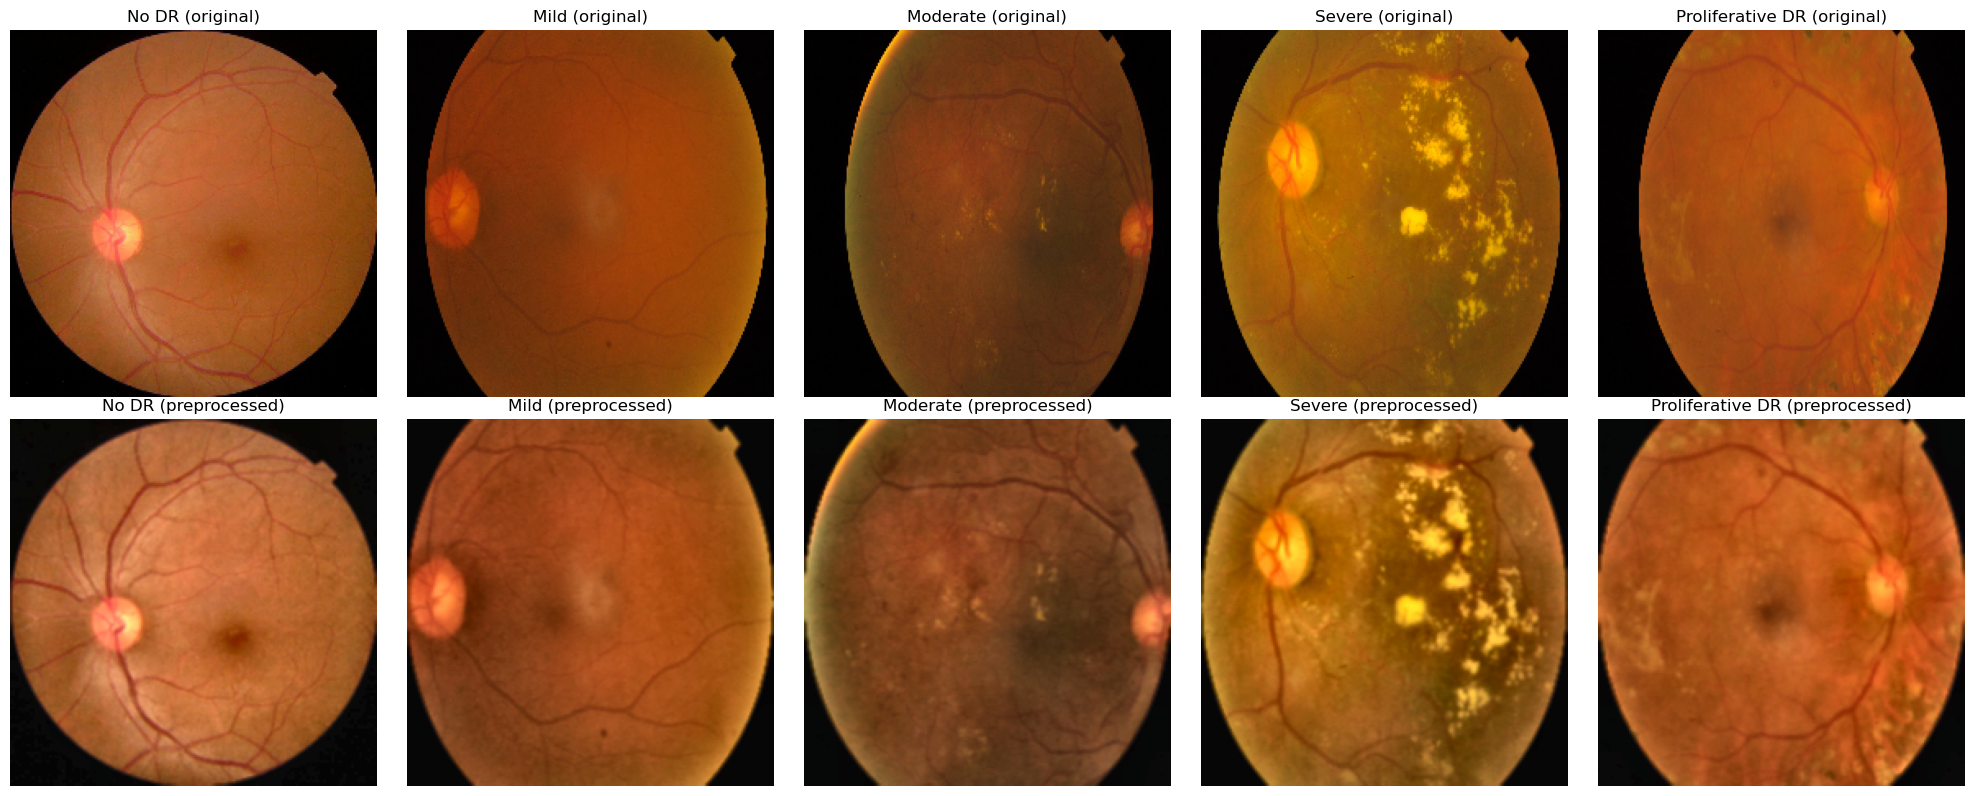

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for label in range(5):
    sample = df[df["diagnosis"] == label].iloc[0]
    original = Image.open(sample["image_path"])
    processed = preprocess_image(sample["image_path"])

    axes[0, label].imshow(original)
    axes[0, label].set_title(f"{class_names[label]} (original)")
    axes[0, label].axis("off")

    axes[1, label].imshow(processed)
    axes[1, label].set_title(f"{class_names[label]} (preprocessed)")
    axes[1, label].axis("off")

plt.tight_layout()
plt.show()

### Run the pipeline over the full dataset

Writes processed images into a mirror of the existing class-folder structure, so any code you already have that expects `colored_images/<class>/<file>` keeps working if you just point it at `colored_images_preprocessed` instead.

In [4]:
try:
    from tqdm import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

os.makedirs(OUTPUT_DIR, exist_ok=True)
for class_folder in os.listdir(IMAGE_DIR):
    os.makedirs(os.path.join(OUTPUT_DIR, class_folder), exist_ok=True)

failed = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    src_path = row["image_path"]
    if pd.isna(src_path):
        continue
    class_folder = os.path.basename(os.path.dirname(src_path))
    dst_path = os.path.join(OUTPUT_DIR, class_folder, os.path.basename(src_path))
    try:
        processed_rgb = preprocess_image(src_path)
        cv2.imwrite(dst_path, cv2.cvtColor(processed_rgb, cv2.COLOR_RGB2BGR))
    except Exception as e:
        failed.append((src_path, str(e)))

print(f"Processed {len(df) - len(failed)} / {len(df)} images. Failures: {len(failed)}")
if failed:
    print("First few failures:", failed[:5])

100%|██████████| 3662/3662 [00:17<00:00, 206.65it/s]

Processed 3662 / 3662 images. Failures: 0


## A note before the next stage (Train / Validation / Test Split)

Your pipeline diagram has the split right after preprocessing, which is correct for the steps above — crop/denoise/CLAHE/resize are deterministic and don't leak information across a split, so it's fine to have already run them on all 3662 images.

**Augmentation is different, and it's worth being deliberate about where it goes.** RSG-Net (Akhtar et al., Sci Rep 2025) generated all its augmented images first (1200 -> 8304) and only *then* split into train/val/test. That means rotated/flipped/zoomed copies of the same original photo could land on both sides of the split — the model can end up being tested on a near-duplicate of something it trained on, which inflates test accuracy. It doesn't invalidate their approach, but it's a real risk with their reported numbers, and it's an easy trap to fall into since it feels natural to "balance the dataset" before splitting.

The safer order:
1. Split first (stratified, so each class keeps its ~49%/27%/10%/8%/5% proportions in train/val/test).
2. Augment only the training set, either on-the-fly (`ImageDataGenerator`/`albumentations` during training) or as a one-time offline expansion — either way, only images inside the training partition ever get transformed copies.
3. Validation and test stay as untouched, real photos throughout, so your reported accuracy reflects performance on images the model has genuinely never seen a version of.

Two starting points for the imbalance itself — you don't have to pick one over the other, but they solve it differently:

In [5]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["diagnosis"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=1/3, stratify=temp_df["diagnosis"], random_state=42
)  # 70 / 10 / 20 overall

print("Train:", train_df.shape[0], " Val:", val_df.shape[0], " Test:", test_df.shape[0])
print("\nClass proportions stay consistent across splits:")
print(pd.DataFrame({
    "train": train_df["diagnosis"].value_counts(normalize=True).sort_index(),
    "val":   val_df["diagnosis"].value_counts(normalize=True).sort_index(),
    "test":  test_df["diagnosis"].value_counts(normalize=True).sort_index(),
}).round(3))

Train: 2563  Val: 732  Test: 367

Class proportions stay consistent across splits:
           train    val   test
diagnosis                     
0          0.493  0.493  0.493
1          0.101  0.101  0.101
2          0.273  0.273  0.272
3          0.053  0.053  0.052
4          0.081  0.079  0.082


In [6]:
# Option A: class_weight — no new images, just tell the loss function to
# penalize mistakes on minority classes more. Simplest, no leakage risk at all.
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.sort(train_df["diagnosis"].unique()),
    y=train_df["diagnosis"]
)
class_weight_dict = dict(enumerate(weights))
print("class_weight:", class_weight_dict)

# Option B: augmentation, applied only to train_df (Keras example).
# fill_mode="constant", cval=0 keeps the black background black instead of
# smearing retina pixels into the corners on rotation/shift.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=(0.85, 1.15),
    fill_mode="constant", cval=0
)
# train_generator = train_datagen.flow_from_dataframe(
#     train_df, x_col="image_path", y_col="class_name",
#     target_size=(TARGET_SIZE, TARGET_SIZE), batch_size=32, class_mode="categorical"
# )

class_weight: {0: np.float64(0.4058590657165479), 1: np.float64(1.9791505791505792), 2: np.float64(0.7333333333333333), 3: np.float64(3.797037037037037), 4: np.float64(2.476328502415459)}
